In [3]:
%matplotlib inline
import os
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

In [4]:
class ShiftMatrix(object):
    # Private method to manipulate and process opinion shift data
    def _manipulate(self, f, accept, reject, total):
        data = json.load(open(f))  # Load JSON data from file `f`
        
        # Iterate through each key in the loaded data (each interaction entry)
        for k in data.keys():
            l = data[k]  # Get the interaction data for key `k`
            d_op = l[0]  # Discussant's opinion
            o_op = l[1]  # Opponent's opinion
            result = l[2]  # Interaction result (accept, reject, or ignore)

            # If the discussant and opponent have the same opinion, skip the interaction
            if d_op == o_op:
                continue

            total[d_op][o_op] += 1  # Increment total interactions for this opinion pair

            # Update the accept or reject matrices based on the interaction result
            if result == "accept":
                accept[d_op][o_op] += 1
            elif result == "reject":
                reject[d_op][o_op] += 1

        # Return the updated matrices
        return accept, reject, total

    def __init__(self, filename: object):
        """
        Initializes the ShiftMatrix object and processes data from one or more files.

        :param filename: A single file or a list of files containing interaction data.
        """
        self.data = {}  # Initialize an empty dictionary to store the processed data
        c = 0  # Unused counter variable

        # Initialize 7x7 matrices for accept, reject, and total counts, all set to 0
        accept = [
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ]
        reject = [
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ]
        total = [
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ]

        # If the filename is a list, process each file in the list
        if isinstance(filename, list):
            for f in filename:
                accept, reject, total = self._manipulate(f, accept, reject, total)
        else:
            # If it's a single file, process that file
            accept, reject, total = self._manipulate(filename, accept, reject, total)

        # Normalize the accept and reject matrices by dividing each element by the corresponding total count
        for i in range(len(total)):
            d = total[i]
            for j in range(len(d)):
                if d[j] > 0:
                    accept[i][j] /= d[j]
                    reject[i][j] /= d[j]

        # Store the normalized accept and reject matrices in the data dictionary
        self.data = {"accept": accept, "reject": reject}
    
    def get_data(self, d='accept'):
        return self.data[d]  
      
    # Method to plot the accept or reject matrix as a heatmap
    def plot(self, ax, d="accept", filename=None):
        """
        Generates the plot for the chosen matrix (accept or reject).

        :param filename: Optional output filename to save the plot.
        :param d: The matrix to plot, either 'accept' or 'reject'.
        """
                
        # Display the chosen matrix as a heatmap with a blue color map
        ax.matshow(self.data[d], cmap="Blues", extent=(0, 7, 7, 0))
        ax.grid(color="w", linestyle="-", linewidth=1, which="minor")  # Add grid lines

        # # Annotate the heatmap with the values for each matrix element
        # for (i, j), z in np.ndenumerate(self.data[d]):
        #     if i != j:  # Avoid annotating the diagonal (same opinion pairs)
        #         ax.text(
        #             j + 0.5,  # X position of the text (column)
        #             i + 0.5,  # Y position of the text (row)
        #             "{:0.1}".format(z),  # Format the value as a string with 2 decimals
        #             ha="center",  # Horizontal alignment
        #             va="center",  # Vertical alignment
        #             size=5,  # Text size
        #             alpha=1,  # Text opacity
        #             color="white"  # Text color
        #         )

        # Set major ticks for the x and y axes
        major_ticks = np.arange(0.5, 7.5, 1)
        ax.set_xticks(major_ticks)  # Set x-axis major ticks
        ax.set_yticks(major_ticks)  # Set y-axis major ticks

        # Set labels for the x and y axes
        ax.set_xticklabels(
            [
                "SD", "D", "MD", "N", "MA", "A", "SA",
            ],
            ha="center",  # Left-align the x-axis labels
            size=6,  # Label size
        )
        ax.set_yticklabels(
            [
                "SD", "D", "MD", "N", "MA", "A", "SA",
            ],
            size=6,  # Label size
            va="center",  # Center-align the y-axis labels
        )

        ax.xaxis.set_ticks_position("bottom")  # Set the x-axis ticks at the bottom
        ax.xaxis.set_tick_params(width=0)
        ax.yaxis.set_tick_params(width=0)
        
        # Label the axes
        ax.set_xlabel("Opponent")  # X-axis label
        ax.set_ylabel("Discussant")  # Y-axis label
        
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        if filename is not None:
            plt.savefig(filename, dpi=300, facecolor='white', bbox_inches='tight')
        else:
            plt.show()
            
        plt.close()

In [ ]:
path = "../../"
c = (1 / 2.54) / 10 
width = 170*c/2
height = 80*c/2

print(width, height)

os.makedirs(path+'figures/shift_matrices/', exist_ok=True)
for d in ['accept', 'reject']:
    for statement in ['min', 'h']:
        for model in ['llama3']:
            for scenario in ['balanced']:
                sm = ShiftMatrix(path+f'results/theseus_theseus_same_llama3.1_0_PAH_{statement}_{model}_{scenario}.json')
                data = sm.get_data(d='accept')
                fig, ax = plt.subplots(figsize=(width, height))
                ax.spines[['right', 'top']].set_visible(False)
                sm.plot(d="accept", ax=ax, filename=path+f'figures/supplementary/theseus_{d}_{statement}_{model}_{scenario}.pdf')

3.3464566929133857 1.574803149606299


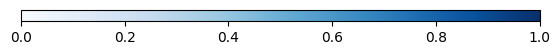

In [12]:
import matplotlib.pyplot as plt
import numpy as np

path = "../../"
c = (1 / 2.54) / 10 
width = 170*c
height = 80*c/2


# Create a figure with a single axis
fig, ax = plt.subplots(figsize=(width, 0.3))  # Adjust width (6) as needed
fig.subplots_adjust(bottom=0.5)

# Create a scalar mappable with the Blues colormap
cmap = plt.cm.Blues
norm = plt.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Create the colorbar
cbar = fig.colorbar(sm, cax=ax, orientation='horizontal', ticks=np.arange(0, 1.1, 0.2))

# Save the figure as a PDF
plt.savefig(path+"figures/colorbar.pdf", bbox_inches='tight', dpi=300)
plt.show()
